# ML Project Workflow Case Study — Synthetic Customer Churn

## From business question to a deployment-ready pipeline

This is a self-contained, expanded version of the linked workflow. It creates a realistic synthetic customer dataset and produces a **result table and chart at every step**.

**Decision:** rank active customers by predicted 30-day churn risk so a capacity-limited retention team can prioritize outreach.

> Synthetic results demonstrate the workflow, not real customer behavior. Re-running with `RANDOM_STATE = 42` reproduces the embedded outputs.

In [1]:
from pathlib import Path
import json, platform, warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, fbeta_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, brier_score_loss)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563eb", "#059669", "#f59e0b", "#dc2626", "#64748b"]
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.options.display.float_format = "{:,.3f}".format

mkdir -p failed for path C:\Users\jacob\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\jacob\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\jacob\AppData\Local\Temp\matplotlib-piu20z06 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1. Define the ML contract

The contract connects the business decision to the prediction unit, horizon, metrics, and operational constraints. Average precision is primary because churn is intentionally imbalanced; the threshold metric emphasizes recall through F2.

,contract_item,definition,decision_importance
0,Decision,Prioritize retention outreach,5
1,Unit,One active customer at weekly scoring,5
2,Target,Churn within the next 30 days,5
3,Features,Only data available at scoring time,5
4,Primary metric,Average precision,4
5,Operating metric,"F2, precision, recall, and capacity",4
6,Guardrails,"Segment outcomes, complaints, lift",3


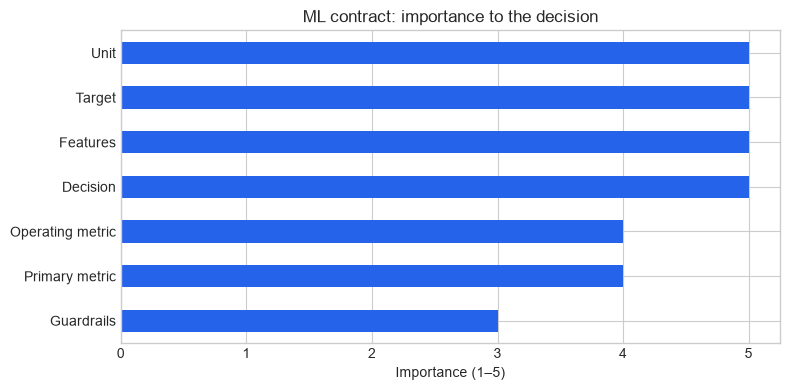

In [2]:
contract = pd.DataFrame([
    ("Decision", "Prioritize retention outreach", 5),
    ("Unit", "One active customer at weekly scoring", 5),
    ("Target", "Churn within the next 30 days", 5),
    ("Features", "Only data available at scoring time", 5),
    ("Primary metric", "Average precision", 4),
    ("Operating metric", "F2, precision, recall, and capacity", 4),
    ("Guardrails", "Segment outcomes, complaints, lift", 3),
], columns=["contract_item", "definition", "decision_importance"])
display(contract)
ax = contract.sort_values("decision_importance").plot.barh(
    x="contract_item", y="decision_importance", legend=False, color=COLORS[0], figsize=(8, 4))
ax.set(title="ML contract: importance to the decision", xlabel="Importance (1–5)", ylabel="")
plt.tight_layout(); plt.show()

## 2. Create and validate synthetic data

The generator encodes plausible relationships: short tenure, frequent support contacts, month-to-month contracts, and payment failures increase churn risk. Missingness is deliberately introduced to exercise the preprocessing pipeline.

,tenure_months,monthly_charges,support_tickets,usage_hours,late_payments,plan,region,contract_type,autopay,churned
0,7,49.107,1,34.054,0,Plus,East,Two year,Yes,0
1,56,39.073,0,55.092,0,Plus,West,Month-to-month,No,0
2,48,101.757,1,NaN,0,Basic,East,Month-to-month,No,0
3,32,125.294,0,35.951,1,Plus,West,Month-to-month,No,0
4,32,61.534,0,45.887,1,Basic,West,Month-to-month,No,0
5,62,42.951,1,50.644,1,Basic,West,Month-to-month,No,0
6,7,22.788,5,36.974,0,Basic,West,One year,Yes,1
7,51,66.630,2,35.638,0,Plus,Central,Two year,Yes,0


,column,dtype,missing_n,missing_pct,unique
0,tenure_months,int64,0,0.000,72
1,monthly_charges,float64,200,2.500,7734
2,support_tickets,int64,0,0.000,9
3,usage_hours,float64,320,4.000,7666
4,late_payments,int64,0,0.000,6
5,plan,str,0,0.000,3
6,region,str,120,1.500,3
7,contract_type,str,0,0.000,3
8,autopay,str,0,0.000,2
9,churned,int64,0,0.000,2


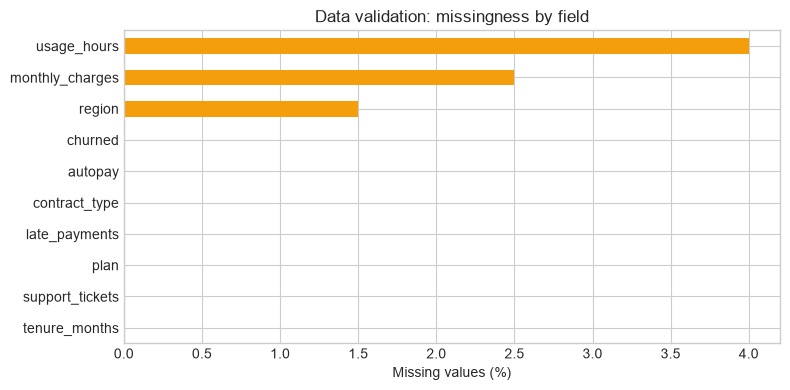

In [3]:
n = 8000
tenure_months = rng.integers(1, 73, n)
monthly_charges = np.clip(rng.normal(72, 22, n), 18, 145)
support_tickets = np.clip(rng.poisson(1.6, n), 0, 9)
usage_hours = np.clip(rng.normal(48, 17, n), 1, 120)
late_payments = np.clip(rng.poisson(0.7, n), 0, 6)
plan = rng.choice(["Basic", "Plus", "Premium"], n, p=[.45, .35, .20])
region = rng.choice(["West", "Central", "East"], n, p=[.38, .29, .33])
contract_type = rng.choice(["Month-to-month", "One year", "Two year"], n, p=[.56, .28, .16])
autopay = rng.choice(["Yes", "No"], n, p=[.62, .38])

logit = (-1.55 - .026 * tenure_months + .018 * (monthly_charges - 70)
         + .30 * support_tickets - .012 * (usage_hours - 45) + .35 * late_payments
         + .85 * (contract_type == "Month-to-month") - .60 * (contract_type == "Two year")
         + .32 * (autopay == "No") + .18 * (plan == "Basic") + rng.normal(0, .55, n))
churn_prob = 1 / (1 + np.exp(-logit))
customers = pd.DataFrame({
    "tenure_months": tenure_months, "monthly_charges": monthly_charges,
    "support_tickets": support_tickets, "usage_hours": usage_hours,
    "late_payments": late_payments, "plan": plan, "region": region,
    "contract_type": contract_type, "autopay": autopay,
    "churned": rng.binomial(1, churn_prob)
})
for column, frac in {"monthly_charges": .025, "usage_hours": .04, "region": .015}.items():
    customers.loc[rng.choice(n, int(n * frac), replace=False), column] = np.nan

quality = pd.DataFrame({
    "dtype": customers.dtypes.astype(str), "missing_n": customers.isna().sum(),
    "missing_pct": 100 * customers.isna().mean(), "unique": customers.nunique()
}).reset_index(names="column")
assert len(customers) == n and customers.churned.isin([0, 1]).all()
display(customers.head(8)); display(quality)
ax = quality.sort_values("missing_pct").plot.barh(
    x="column", y="missing_pct", legend=False, color=COLORS[2], figsize=(8, 4))
ax.set(title="Data validation: missingness by field", xlabel="Missing values (%)", ylabel="")
plt.tight_layout(); plt.show()

## 3. Explore the target and business segments

EDA checks prevalence and where risk is concentrated. These are descriptive associations—not causal effects.

,customers,churn_rate,avg_tenure,avg_tickets
contract_type,,,,
Month-to-month,4442,0.364,35.869,1.592
One year,2240,0.219,36.881,1.630
Two year,1318,0.149,35.890,1.610


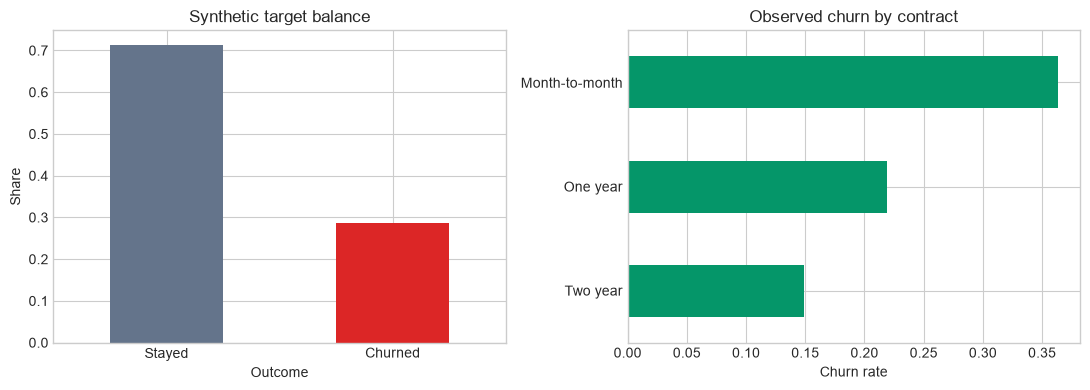

In [4]:
segment_summary = (customers.groupby("contract_type", observed=True)
                   .agg(customers=("churned", "size"), churn_rate=("churned", "mean"),
                        avg_tenure=("tenure_months", "mean"), avg_tickets=("support_tickets", "mean"))
                   .sort_values("churn_rate", ascending=False))
display(segment_summary)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
customers.churned.value_counts(normalize=True).sort_index().rename(index={0:"Stayed",1:"Churned"}).plot.bar(
    ax=axes[0], color=[COLORS[4], COLORS[3]], rot=0)
segment_summary.churn_rate.sort_values().plot.barh(ax=axes[1], color=COLORS[1])
axes[0].set(title="Synthetic target balance", ylabel="Share", xlabel="Outcome")
axes[1].set(title="Observed churn by contract", xlabel="Churn rate", ylabel="")
plt.tight_layout(); plt.show()

## 4. Split before preprocessing and build a leakage-safe pipeline

The test set is isolated before learning imputations, encodings, scales, coefficients, or thresholds. A temporal split is preferable when dated production records are available.

,rows,churn_rate,used_for
fit,4800,0.288,Fit/CV
validation,1600,0.287,Threshold selection
test,1600,0.287,Final unbiased evaluation


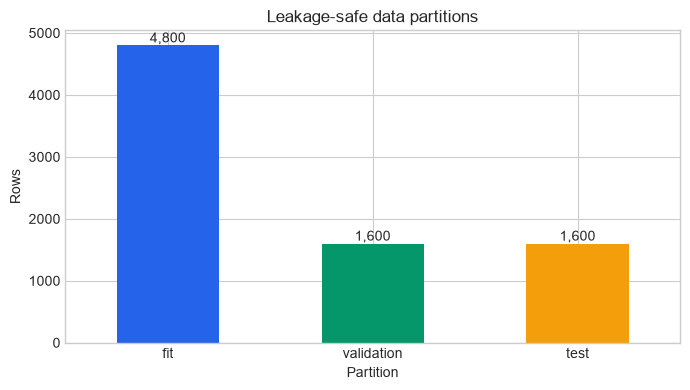

,feature_group,columns,pipeline_actions
0,Numeric,"tenure_months, monthly_charges, support_ticket...",Median imputation + standardization
1,Categorical,"plan, region, contract_type, autopay",Mode imputation + one-hot encoding


In [5]:
X = customers.drop(columns="churned"); y = customers.churned
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train, y_train, test_size=.25, stratify=y_train, random_state=RANDOM_STATE)

split_summary = pd.DataFrame({
    "rows": [len(X_fit), len(X_valid), len(X_test)],
    "churn_rate": [y_fit.mean(), y_valid.mean(), y_test.mean()],
    "used_for": ["Fit/CV", "Threshold selection", "Final unbiased evaluation"]
}, index=["fit", "validation", "test"])
display(split_summary)
ax = split_summary.rows.plot.bar(color=COLORS[:3], rot=0, figsize=(7, 4))
ax.set(title="Leakage-safe data partitions", ylabel="Rows", xlabel="Partition")
for p in ax.patches: ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout(); plt.show()

numeric = X.select_dtypes(include="number").columns.tolist()
categorical = X.select_dtypes(exclude="number").columns.tolist()
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical)
])
pipeline = Pipeline([("preprocess", preprocess),
                     ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))])
prep_table = pd.DataFrame([
    ("Numeric", ", ".join(numeric), "Median imputation + standardization"),
    ("Categorical", ", ".join(categorical), "Mode imputation + one-hot encoding")
], columns=["feature_group", "columns", "pipeline_actions"])
display(prep_table)

## 5. Establish a baseline and tune with cross-validation

The tuned model must beat a prevalence-only baseline. The train–validation gap helps reveal overfitting.

,model,validation_average_precision
0,Prior baseline,0.287
1,Tuned logistic regression,0.508


,param_model__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,0.030,0.512,0.508,0.029,1
1,0.100,0.512,0.508,0.029,2
3,1.000,0.512,0.508,0.029,3
2,0.300,0.512,0.508,0.029,4
4,3.000,0.512,0.508,0.029,5
5,10.000,0.512,0.508,0.029,6


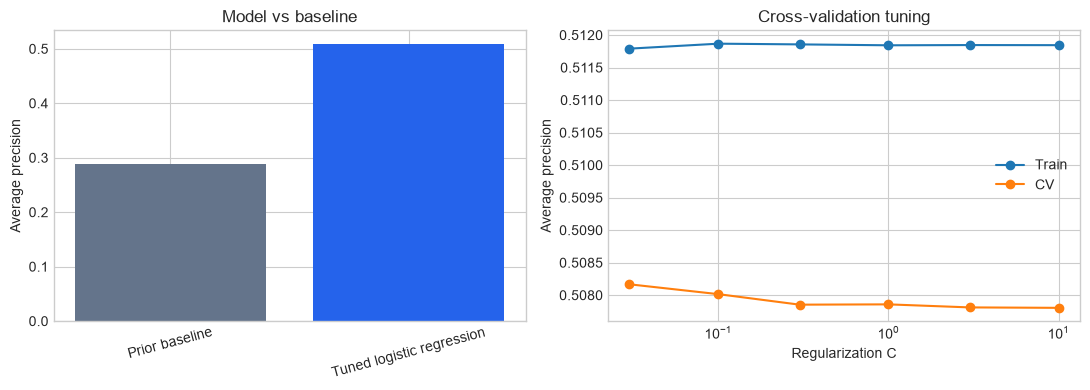

In [6]:
baseline = DummyClassifier(strategy="prior").fit(X_fit, y_fit)
baseline_ap = average_precision_score(y_valid, baseline.predict_proba(X_valid)[:, 1])
search = GridSearchCV(pipeline, {"model__C": [.03, .1, .3, 1, 3, 10]},
                      scoring="average_precision", cv=5, n_jobs=1, return_train_score=True)
search.fit(X_fit, y_fit)
cv_results = (pd.DataFrame(search.cv_results_)
              [["param_model__C", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]]
              .sort_values("param_model__C"))
comparison = pd.DataFrame({"model": ["Prior baseline", "Tuned logistic regression"],
                           "validation_average_precision": [baseline_ap, search.best_score_]})
display(comparison); display(cv_results.sort_values("rank_test_score"))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(comparison.model, comparison.validation_average_precision, color=[COLORS[4], COLORS[0]])
axes[0].tick_params(axis="x", rotation=15); axes[0].set(title="Model vs baseline", ylabel="Average precision")
axes[1].plot(cv_results.param_model__C.astype(float), cv_results.mean_train_score, marker="o", label="Train")
axes[1].plot(cv_results.param_model__C.astype(float), cv_results.mean_test_score, marker="o", label="CV")
axes[1].set_xscale("log"); axes[1].set(title="Cross-validation tuning", xlabel="Regularization C", ylabel="Average precision"); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Select the operating threshold

The model score is converted into an action using validation data only. F2 weights recall more heavily than precision; production selection should also encode outreach capacity and real costs.

,threshold,precision,recall,f2,customers_flagged
0,0.361,0.373,0.902,0.702,1114
1,0.469,0.416,0.724,0.631,800
2,0.546,0.484,0.589,0.565,560
3,0.607,0.537,0.467,0.480,400
4,0.677,0.600,0.313,0.346,240
5,0.727,0.625,0.217,0.250,160


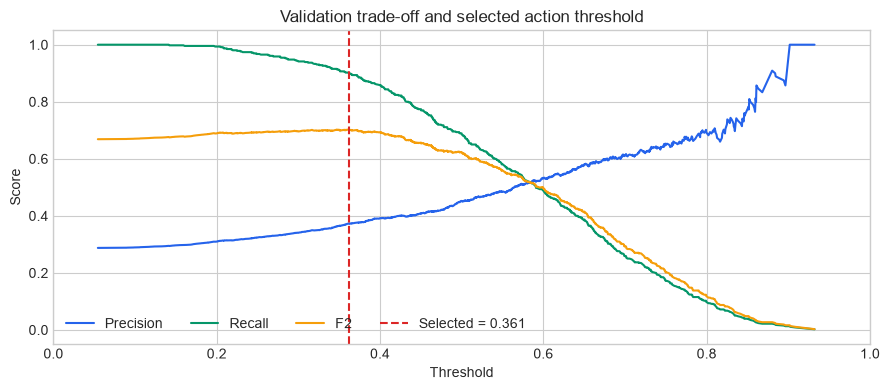

In [7]:
valid_prob = search.predict_proba(X_valid)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_valid, valid_prob)
f2 = 5 * precision[:-1] * recall[:-1] / (4 * precision[:-1] + recall[:-1] + 1e-12)
best_i = int(np.nanargmax(f2)); threshold = float(thresholds[best_i])
candidate_thresholds = np.unique(np.r_[np.quantile(valid_prob, [.50, .65, .75, .85, .90]), threshold])
threshold_table = pd.DataFrame([{
    "threshold": t, "precision": precision_score(y_valid, valid_prob >= t, zero_division=0),
    "recall": recall_score(y_valid, valid_prob >= t),
    "f2": fbeta_score(y_valid, valid_prob >= t, beta=2),
    "customers_flagged": int((valid_prob >= t).sum())
} for t in candidate_thresholds]).sort_values("threshold")
display(threshold_table)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precision[:-1], label="Precision", color=COLORS[0]); ax.plot(thresholds, recall[:-1], label="Recall", color=COLORS[1])
ax.plot(thresholds, f2, label="F2", color=COLORS[2]); ax.axvline(threshold, color=COLORS[3], ls="--", label=f"Selected = {threshold:.3f}")
ax.set(title="Validation trade-off and selected action threshold", xlabel="Threshold", ylabel="Score", xlim=(0,1)); ax.legend(ncol=4)
plt.tight_layout(); plt.show()

## 7. Perform final held-out evaluation

Only after tuning and threshold selection is the untouched test set evaluated.

,value
ROC AUC,0.731
Average precision,0.527
Precision @ threshold,0.371
Recall @ threshold,0.878
F2 @ threshold,0.690
Brier score (lower is better),0.209


,Predict stay,Predict churn
Actual stay,455,685
Actual churn,56,404


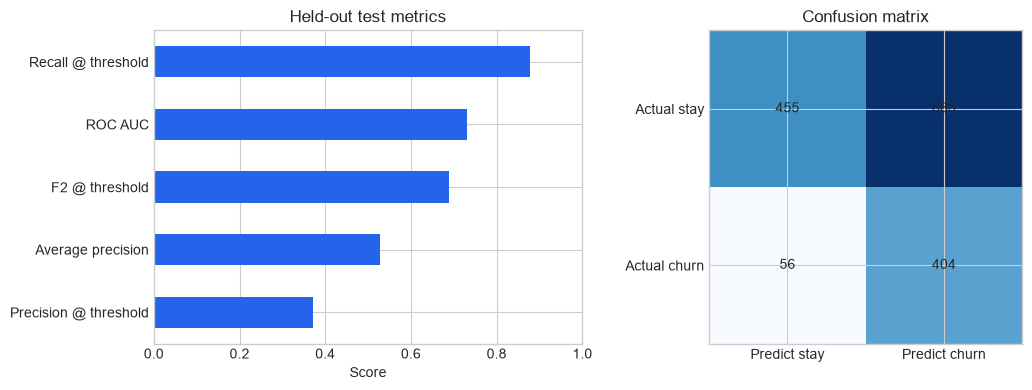

In [8]:
model = search.best_estimator_.fit(X_train, y_train)
test_prob = model.predict_proba(X_test)[:, 1]; test_pred = (test_prob >= threshold).astype(int)
test_metrics = pd.DataFrame({"value": {
    "ROC AUC": roc_auc_score(y_test, test_prob),
    "Average precision": average_precision_score(y_test, test_prob),
    "Precision @ threshold": precision_score(y_test, test_pred),
    "Recall @ threshold": recall_score(y_test, test_pred),
    "F2 @ threshold": fbeta_score(y_test, test_pred, beta=2),
    "Brier score (lower is better)": brier_score_loss(y_test, test_prob)
}})
cm = pd.DataFrame(confusion_matrix(y_test, test_pred),
                  index=["Actual stay", "Actual churn"], columns=["Predict stay", "Predict churn"])
display(test_metrics); display(cm)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
test_metrics.drop(index="Brier score (lower is better)").sort_values("value").plot.barh(
    ax=axes[0], legend=False, color=COLORS[0])
axes[0].set(title="Held-out test metrics", xlabel="Score", ylabel="", xlim=(0,1))
im = axes[1].imshow(cm.values, cmap="Blues")
for (i, j), value in np.ndenumerate(cm.values): axes[1].text(j, i, f"{value:,}", ha="center", va="center")
axes[1].set(xticks=[0,1], yticks=[0,1], xticklabels=cm.columns, yticklabels=cm.index, title="Confusion matrix")
plt.tight_layout(); plt.show()

## 8. Diagnose calibration, slices, and explainability

Calibration checks whether scores behave like probabilities. Slice metrics can expose uneven performance. Permutation importance is predictive—not causal—and slice checks are not a complete fairness assessment.

,mean_predicted_risk,observed_churn_rate
0,0.160,0.069
1,0.250,0.100
2,0.317,0.144
3,0.378,0.219
4,0.437,0.250
5,0.489,0.281
6,0.544,0.263
7,0.611,0.444
8,0.686,0.487
9,0.790,0.619


,customers,actual_rate,mean_score,precision,recall
plan,,,,,
Basic,704.000,0.317,0.487,0.386,0.888
Plus,572.000,0.271,0.448,0.363,0.852
Premium,324.000,0.253,0.454,0.349,0.902


,feature,importance_mean,importance_std
7,contract_type,0.085,0.009
0,tenure_months,0.085,0.013
1,monthly_charges,0.065,0.006
2,support_tickets,0.041,0.011
4,late_payments,0.022,0.007
3,usage_hours,0.015,0.002
5,plan,0.006,0.003
8,autopay,0.005,0.006
6,region,-0.000,0.000


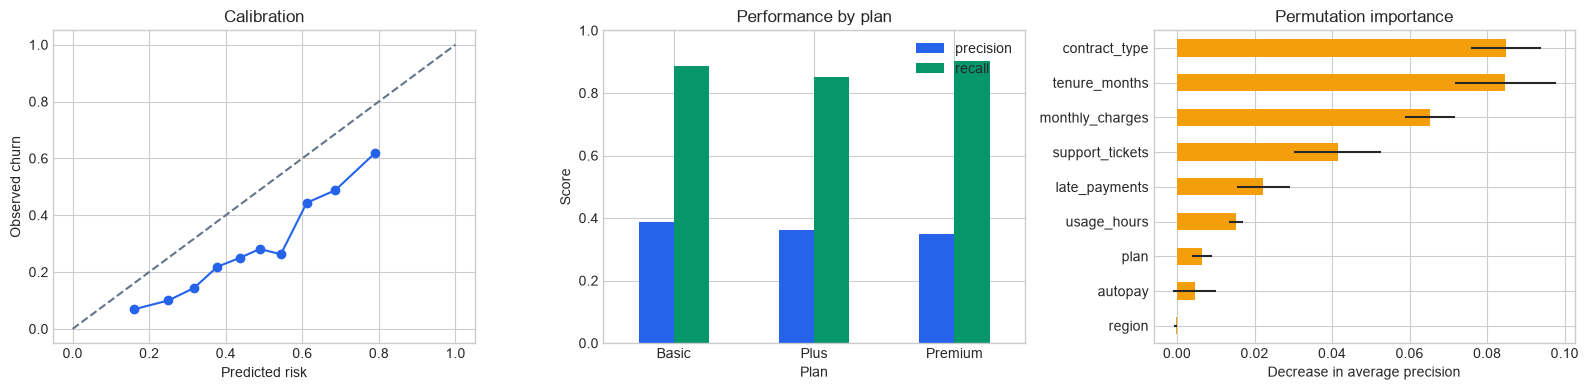

In [9]:
fraction, mean_score = calibration_curve(y_test, test_prob, n_bins=10, strategy="quantile")
calibration_table = pd.DataFrame({"mean_predicted_risk": mean_score, "observed_churn_rate": fraction})
scored = X_test[["plan", "region", "contract_type"]].copy()
scored["actual"] = y_test.to_numpy(); scored["score"] = test_prob; scored["prediction"] = test_pred
slice_table = (scored.groupby("plan", observed=True)
               .apply(lambda g: pd.Series({"customers": len(g), "actual_rate": g.actual.mean(),
                                           "mean_score": g.score.mean(),
                                           "precision": precision_score(g.actual, g.prediction, zero_division=0),
                                           "recall": recall_score(g.actual, g.prediction, zero_division=0)}),
                      include_groups=False))
importance = permutation_importance(model, X_test, y_test, scoring="average_precision",
                                    n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
importance_table = pd.DataFrame({"feature": X_test.columns,
                                 "importance_mean": importance.importances_mean,
                                 "importance_std": importance.importances_std}).sort_values("importance_mean", ascending=False)
display(calibration_table); display(slice_table); display(importance_table)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot([0,1],[0,1], ls="--", color=COLORS[4]); axes[0].plot(mean_score, fraction, marker="o", color=COLORS[0])
axes[0].set(title="Calibration", xlabel="Predicted risk", ylabel="Observed churn")
slice_table[["precision", "recall"]].plot.bar(ax=axes[1], color=[COLORS[0], COLORS[1]], rot=0)
axes[1].set(title="Performance by plan", ylabel="Score", xlabel="Plan", ylim=(0,1))
importance_table.sort_values("importance_mean").plot.barh(
    x="feature", y="importance_mean", xerr="importance_std", ax=axes[2], legend=False, color=COLORS[2])
axes[2].set(title="Permutation importance", xlabel="Decrease in average precision", ylabel="")
plt.tight_layout(); plt.show()

## 9. Package the complete inference pipeline

The serialized pipeline contains imputation, encoding, scaling, and the estimator. Metadata makes the decision threshold and expected schema explicit.

,artifact,size_kb,purpose
0,churn_pipeline.joblib,5.072,Complete inference pipeline
1,feature_importance.csv,0.521,Explainability snapshot
2,model_metadata.json,0.383,"Schema, threshold, and metrics"
3,sample_predictions.csv,1.898,Example scored output


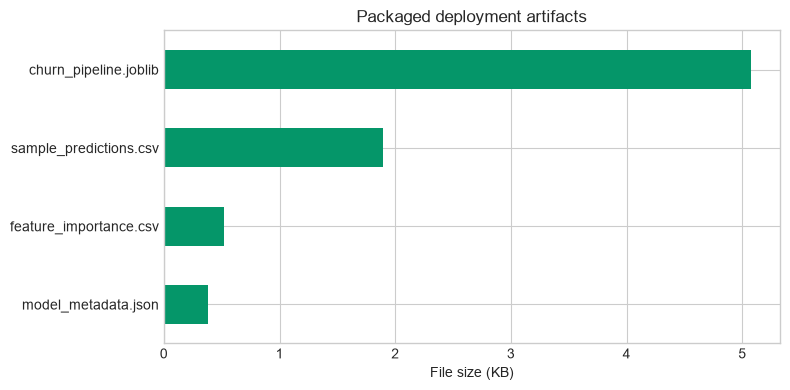

In [10]:
ARTIFACT_DIR = Path("notebook_case_study_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(model, ARTIFACT_DIR / "churn_pipeline.joblib")
metadata = {
    "target": "30_day_churn", "threshold": threshold,
    "roc_auc": float(test_metrics.loc["ROC AUC", "value"]),
    "average_precision": float(test_metrics.loc["Average precision", "value"]),
    "features": list(X_test.columns), "random_state": RANDOM_STATE,
    "python": platform.python_version()
}
(ARTIFACT_DIR / "model_metadata.json").write_text(json.dumps(metadata, indent=2))
importance_table.to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)
sample = X_test.head(20).copy(); sample["predicted_churn_risk"] = test_prob[:20]
sample.to_csv(ARTIFACT_DIR / "sample_predictions.csv", index=False)
manifest = pd.DataFrame([{"artifact": p.name, "size_kb": p.stat().st_size / 1024,
                          "purpose": {"churn_pipeline.joblib":"Complete inference pipeline",
                                      "model_metadata.json":"Schema, threshold, and metrics",
                                      "feature_importance.csv":"Explainability snapshot",
                                      "sample_predictions.csv":"Example scored output"}[p.name]}
                         for p in sorted(ARTIFACT_DIR.iterdir())])
display(manifest)
ax = manifest.sort_values("size_kb").plot.barh(x="artifact", y="size_kb", legend=False, color=COLORS[1], figsize=(8,4))
ax.set(title="Packaged deployment artifacts", xlabel="File size (KB)", ylabel="")
plt.tight_layout(); plt.show()

## 10. Simulate deployment monitoring and retraining signals

Production monitoring should combine system health, data quality, score drift, delayed performance, calibration, slice metrics, and incremental retention from randomized holdouts. The synthetic weeks below illustrate a drift alert rather than a real production claim.

,week,missingness_pct,score_mean,average_precision,p95_latency_ms,alert
0,2026-01-05,3.566,0.486,0.520,126.029,OK
1,2026-01-12,2.695,0.472,0.517,97.990,OK
2,2026-01-19,3.190,0.477,0.532,108.566,OK
3,2026-01-26,2.707,0.461,0.516,113.244,OK
4,2026-02-02,4.279,0.475,0.544,104.574,OK
5,2026-02-09,2.658,0.468,0.531,123.801,OK
6,2026-02-16,3.938,0.458,0.524,115.407,OK
7,2026-02-23,2.892,0.504,0.529,101.509,OK
8,2026-03-02,2.710,0.465,0.525,100.168,OK
9,2026-03-09,4.185,0.497,0.522,114.965,OK


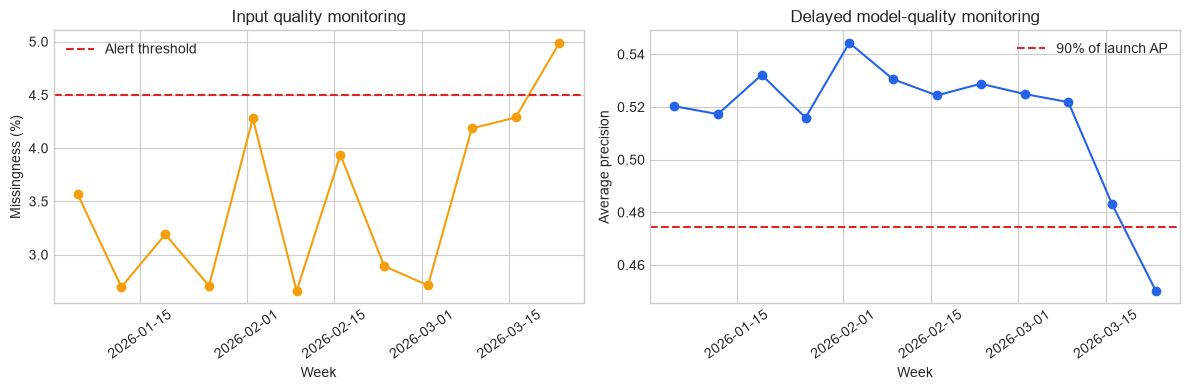

,stage,control,cadence
0,Deploy,Weekly batch scoring; schema checks; version m...,Before every scoring run
1,Monitor,"Latency, failures, missingness, score drift, r...",Weekly; labels when available
2,Investigate,Trace pipeline/data changes; compare slices an...,On alert
3,Retrain,Champion–challenger test on frozen temporal ba...,After confirmed degradation/new labels
4,Measure impact,Randomized holdout for incremental retention a...,Every campaign


In [11]:
weeks = pd.date_range("2026-01-05", periods=12, freq="W-MON")
monitoring = pd.DataFrame({
    "week": weeks,
    "missingness_pct": np.clip(rng.normal(3.0, .45, 12) + np.r_[np.zeros(9), [1.2, 1.8, 2.4]], 0, None),
    "score_mean": np.clip(rng.normal(test_prob.mean(), .012, 12) + np.r_[np.zeros(8), [.015, .03, .05, .07]], 0, 1),
    "average_precision": np.clip(rng.normal(test_metrics.loc["Average precision", "value"], .015, 12)
                                 - np.r_[np.zeros(8), [.01, .025, .05, .08]], 0, 1),
    "p95_latency_ms": np.clip(rng.normal(115, 12, 12), 70, None)
})
monitoring["alert"] = ((monitoring.missingness_pct > 4.5) |
                       (monitoring.average_precision < .90 * test_metrics.loc["Average precision", "value"])).map({True:"Investigate", False:"OK"})
display(monitoring)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(monitoring.week, monitoring.missingness_pct, marker="o", color=COLORS[2]); axes[0].axhline(4.5, ls="--", color=COLORS[3], label="Alert threshold")
axes[0].set(title="Input quality monitoring", ylabel="Missingness (%)", xlabel="Week"); axes[0].legend()
axes[1].plot(monitoring.week, monitoring.average_precision, marker="o", color=COLORS[0]); axes[1].axhline(.90 * test_metrics.loc["Average precision", "value"], ls="--", color=COLORS[3], label="90% of launch AP")
axes[1].set(title="Delayed model-quality monitoring", ylabel="Average precision", xlabel="Week"); axes[1].legend()
for ax in axes: ax.tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()

action_table = pd.DataFrame([
    ("Deploy", "Weekly batch scoring; schema checks; version model + threshold", "Before every scoring run"),
    ("Monitor", "Latency, failures, missingness, score drift, ranking, slices", "Weekly; labels when available"),
    ("Investigate", "Trace pipeline/data changes; compare slices and calibration", "On alert"),
    ("Retrain", "Champion–challenger test on frozen temporal backtest", "After confirmed degradation/new labels"),
    ("Measure impact", "Randomized holdout for incremental retention and complaints", "Every campaign")
], columns=["stage", "control", "cadence"])
display(action_table)

## Conclusions and limitations

- A useful ML system is a controlled decision process, not just a fitted estimator.
- The synthetic data makes the full workflow runnable without private customer records.
- The selected F2 threshold is illustrative; a real threshold should encode outreach capacity, costs, and expected incremental benefit.
- Logistic regression should be compared with nonlinear challengers on a frozen temporal backtest.
- Churn risk is not persuadability. Retention impact requires randomized experimentation.